In [1]:
# this allows plots to appear directly in the notebook
%matplotlib inline

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter('ignore')

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

### Read the column description and ensure you understand each attribute well

In [3]:
bank_df = pd.read_csv('C:\AIML\Assessment\R3\External Assessment\Bank_Personal_Loan_Modelling-1.csv')
bank_df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


From the dataset, following are my understanding.

Nominal Variables:
1. 'ID' is a serial number which is a customer ID and can be ignored.
2. 'ZIP code' is a home address zip code of a customer and can be ignored.

Ordinal Variables:
1. 'Family' denotes number of family members of a customer.
2. 'Education' denotes level of education of a customer. In this dataset, the Education value ranges from 1 to 3. 
    1 - under graduate, 2 - Graduate and 3 - Post graduate.

Interval Variables :

1. 'Age' refers Age of the customer. Age values ranges between 23 to 67.
2. 'Experience' refers Years of experience of a customer. Value ranges from -3 to 43.
3. 'Income' refers to Annual Income of the customer.
4. 'CCAvg' refers Avg. spending on credit cards per month.
5. 'Mortgage' refers Value of House Mortgage.

Binary Categorical Variable :

1. 'Securities Account' means Does the customer have Security Account with bank or not? 
    0 - has no security account, 1 - has security account.
            
2. 'CD Account' means Does the customer have CD Account with bank or not?
    0 - has no CD account, 1 - has CD account.
    
3. 'Online' means Does the customer have Online banking with bank or not?
     0 - has no OLB account, 1 - has OLB account.
     
4. 'CreditCard' - Does the customer have a credit card issued by Bank or not?
    0 - has no creditCard, 1 - has credit card.

Target Categorical Variable:

1. 'Personal Loan' - This our target variable which we have to predict. 
    0 - customer has not availed personal loan,  1 - Customer has availed personal loan.

In [4]:
#Total number of rows and columns in dataset.
bank_df.shape

(5000, 14)

In [5]:
# Look at the datatype of each column
bank_df.dtypes

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

In [6]:
#High Level view of each column and datatype
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [7]:
#Look at the statistical description of each column
bank_df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


###### From the dataset, it is observed that Experience has negative values which needs to be transformed. The Experience column cannot have a negative value.

In [8]:
#Look for missing values if any
bank_df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [9]:
#Five point summary of all features in the dataset.
bank_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [10]:
#There are totally 52 negative values in the Experience. The Experiene column cannot have -ve values as this has no meaning. 
#Let's clean up the data in Experience column.

print("Total # of negative values in Experience Column:", bank_df[bank_df['Experience'] < 0]['Experience'].count() )

bank_df[bank_df['Experience'] < 0]['Experience'].value_counts()

Total # of negative values in Experience Column: 52


-1    33
-2    15
-3     4
Name: Experience, dtype: int64

In [11]:
bank_df['Experience']=bank_df['Experience'].apply(lambda x: bank_df['Experience'].median() if(x < 0) else x)

In [12]:
# Total records of negative experience
bank_df[bank_df['Experience'] < 0]['Experience'].count()

0

In [13]:
#Now we can see the min is 0.0 which was -3.0 before error fixing.
bank_df['Experience'].describe().T

count    5000.000000
mean       20.327600
std        11.253035
min         0.000000
25%        11.000000
50%        20.000000
75%        30.000000
max        43.000000
Name: Experience, dtype: float64

##### Relationship between each feature.

In [14]:
bank_df.corr()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,1.000000,-0.008473,-0.009339,-0.017695,0.013432,-0.016797,-0.024675,0.021463,-0.013920,-0.024801,-0.016972,-0.006909,-0.002528,0.017028
Age,-0.008473,1.000000,0.977182,-0.055269,-0.029216,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,-0.009339,0.977182,1.000000,-0.049046,-0.028492,-0.045528,-0.048718,0.018074,-0.013365,-0.014013,-0.000465,0.005526,0.013459,0.008834
Income,-0.017695,-0.055269,-0.049046,1.000000,-0.016410,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIP Code,0.013432,-0.029216,-0.028492,-0.016410,1.000000,0.011778,-0.004061,-0.017377,0.007383,0.000107,0.004704,0.019972,0.016990,0.007691
Family,-0.016797,-0.046418,-0.045528,-0.157501,0.011778,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.024675,-0.052012,-0.048718,0.645984,-0.004061,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.021463,0.041334,0.018074,-0.187524,-0.017377,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.013920,-0.012539,-0.013365,0.206806,0.007383,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.024801,-0.007726,-0.014013,0.502462,0.000107,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802


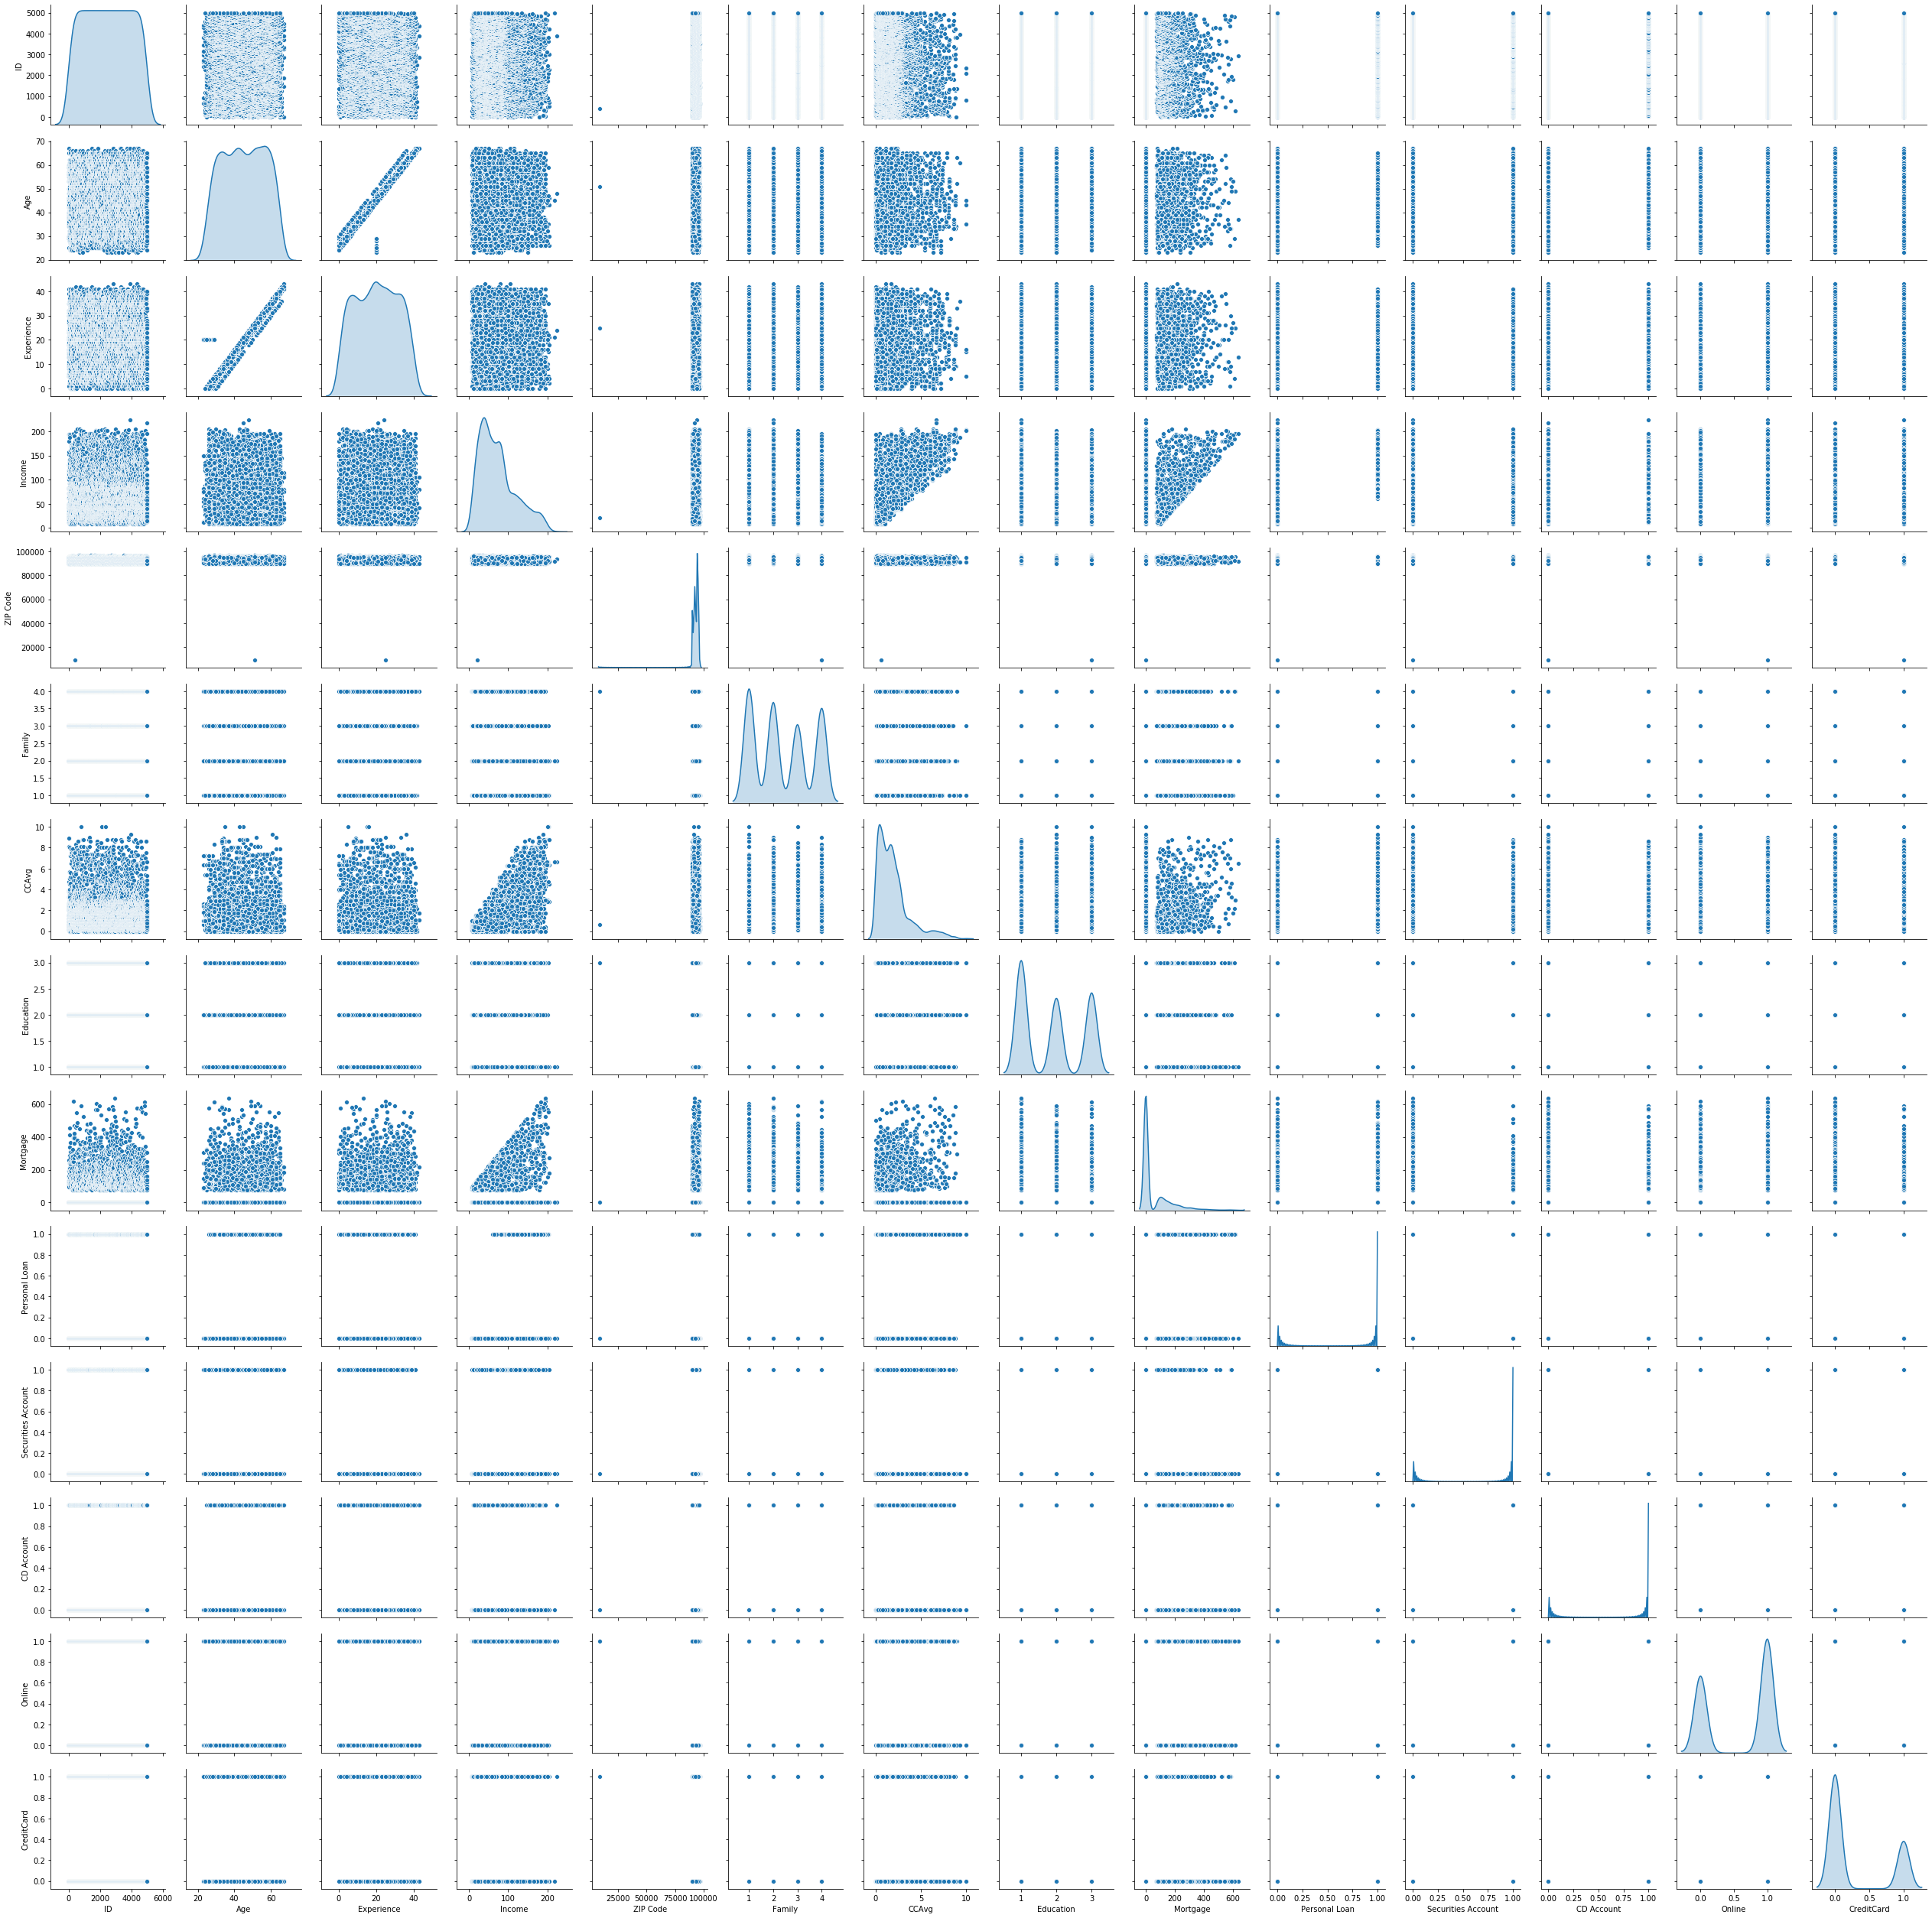

In [15]:
sns.pairplot(data=bank_df,diag_kind ='kde')

#### Question #2: Study the data distribution in each attribute, share your findings

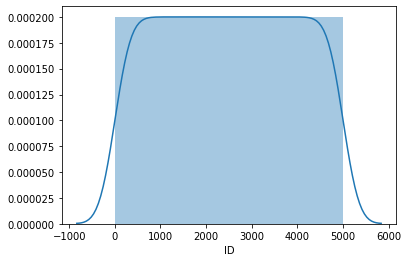

In [16]:
sns.distplot(bank_df['ID'])

Comments: Though ID column has normal distribution, it is a customer ID and has no significance in predicting the personal loan.

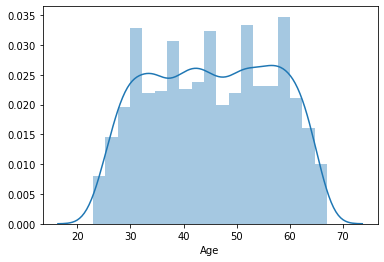

In [17]:
sns.distplot(bank_df['Age'])

comments: There are 3 small peaks in the distribution indicates 3 Age values (between 30 to 38, 42 to 48 and 55 to 60) are high in number. Though it shows a normal distribution.

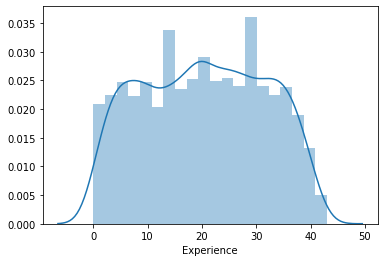

In [18]:
sns.distplot(bank_df['Experience'])

Comments: The graph shows it is distributed normaly. By looking at the descriptive statistics, the mean and median has same value and hence it has normal distribution.

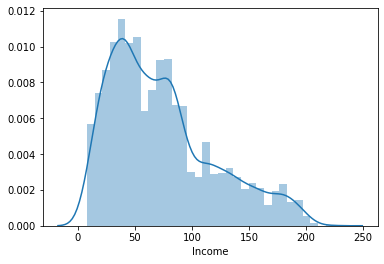

In [19]:
sns.distplot(bank_df['Income'])

Comments: The Income variable distribution has a right skewness as it has a right tail.

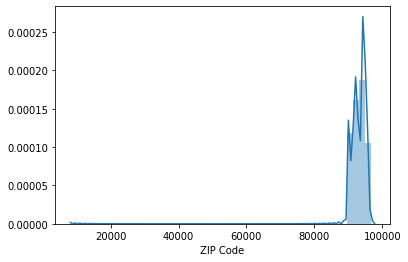

In [20]:
sns.distplot(bank_df['ZIP Code'])

Comments: The distribution has a high peak in specific range which tells that customers are from specific area are high in number.

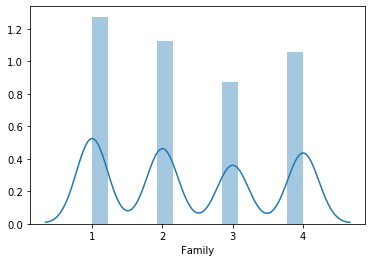

In [21]:
sns.distplot(bank_df['Family'])

Comments: Distribution shows Family 1 and 2 are high in number.

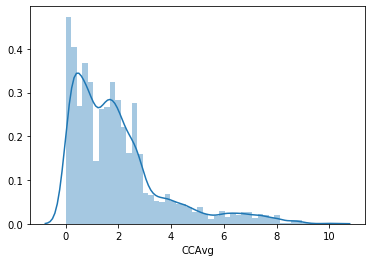

In [22]:
sns.distplot(bank_df['CCAvg'])

Comments: The distribution is right skewed as the tail is towards right side.
    The distribution shows number of customers spending between 1K and 3 K on monthly are more in number. 
    Very few customers spend around 4K to 8K on monthly.

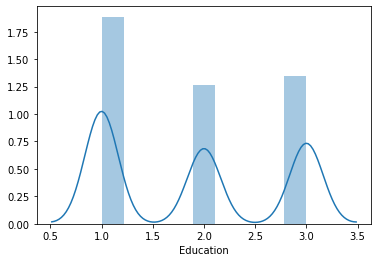

In [23]:
sns.distplot(bank_df['Education'])

Comments: From distribution, it is clear that undergraduate customer are more than graduate and post graduate customers.

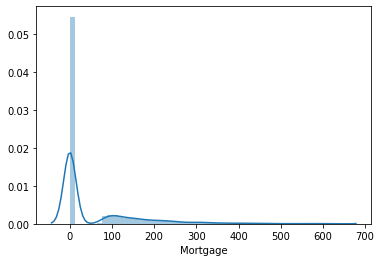

In [24]:
sns.distplot(bank_df['Mortgage'])

Comments: The distribution is right skewed as the tail is towards right side.
It is observed that very few has mortgage with the bank and very few customers has mortage more than 80K.

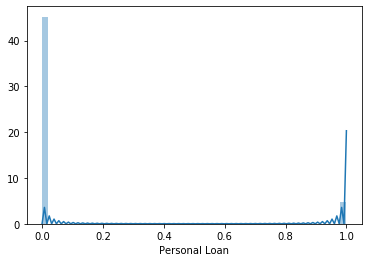

In [25]:
sns.distplot(bank_df['Personal Loan'])

In [26]:
bank_df["Personal Loan"].value_counts()

0    4520
1     480
Name: Personal Loan, dtype: int64

Comments: This is the target variable. The distribution shows that only few customers has availed personal loan already.

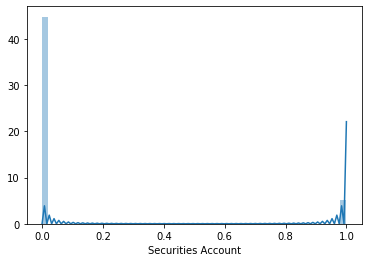

In [27]:
sns.distplot(bank_df['Securities Account'])

Comments: The distribution shows very few customers has security account in bank.

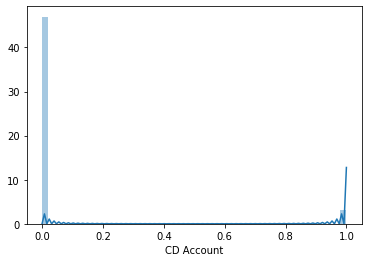

In [28]:
sns.distplot(bank_df['CD Account'])

Comments: From the distribution, it appears very few customers have CD account with bank.

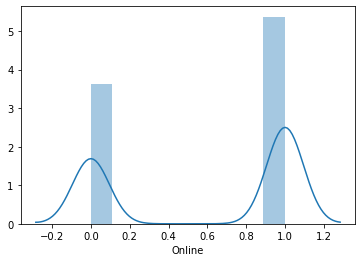

In [29]:
sns.distplot(bank_df['Online'])

Comments: The graph shows that number of customers using online banking is more than customers who don't use OLB.

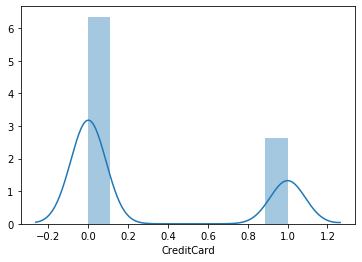

In [30]:
sns.distplot(bank_df['CreditCard'])

Comments: The distribution shows that few customers own credit card compared to non-credit card customers.

### Question #3 : Get the target column distribution. Your comments

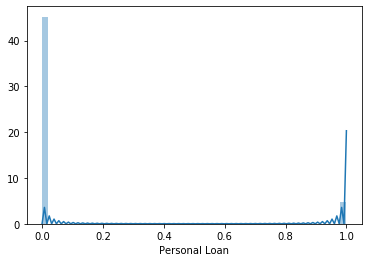

In [31]:
#Personal Loan is the target variable.
sns.distplot(bank_df['Personal Loan'])

In [32]:
bank_df['Personal Loan'].value_counts()

0    4520
1     480
Name: Personal Loan, dtype: int64

Comments: Out of total 5000 customers, 480 customers availed personal loan from previous campaign held by Bank last year
remaining 4520 customers haven't availed personal loan.

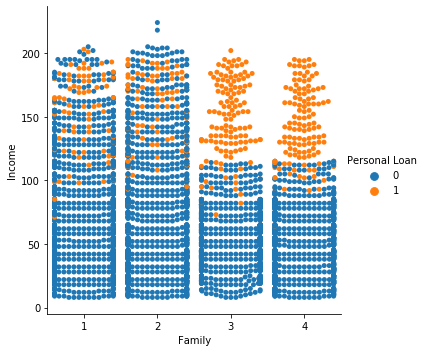

In [33]:
sns.catplot(x='Family', y='Income', hue='Personal Loan', data = bank_df, kind='swarm')

Customers with family members 3 or 4 earning more than 100K are more likely to take Personal Loan.

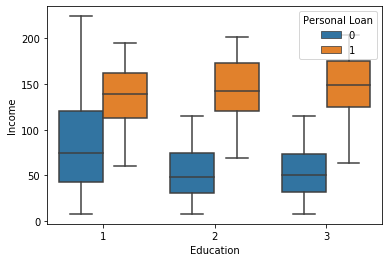

In [34]:
sns.boxplot(x='Education', y='Income', data=bank_df, hue='Personal Loan')

Education with graduate / post grad are more likely to take loan compared to undergrad.

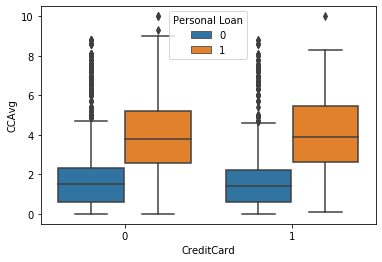

In [35]:
sns.boxplot(x="CreditCard", y='CCAvg', hue="Personal Loan", data=bank_df)

Customers with credit card and spending more on monthly basis are more likely to take personal loan.

Text(0.5, 1.0, 'Income Distribution')

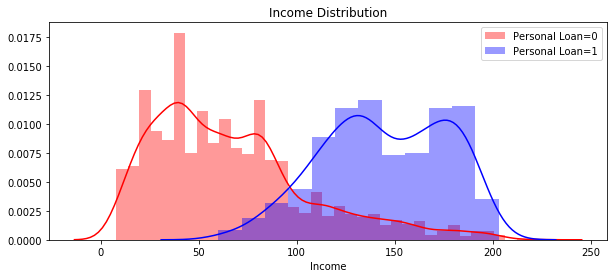

In [37]:
plt.figure(figsize=(10,4))
sns.distplot(bank_df[bank_df["Personal Loan"] == 0]['Income'], color = 'r',label='Personal Loan=0')
sns.distplot(bank_df[bank_df["Personal Loan"] == 1]['Income'], color = 'b',label='Personal Loan=1')
plt.legend()
plt.title("Income Distribution")

Customers with high income have availed Personal Loan and high income would be a good predictor to design a model.

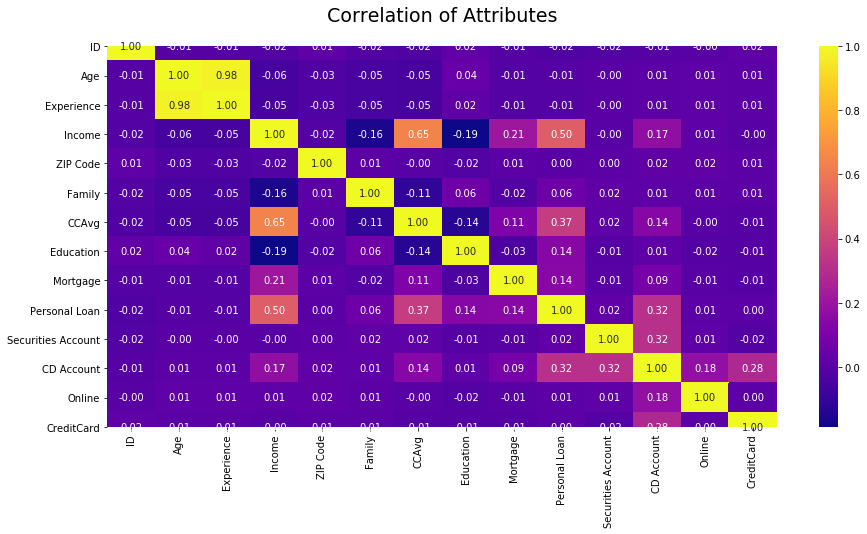

In [38]:
plt.figure(figsize = (15,7))
plt.title('Correlation of Attributes', y=1.05, size=19)
sns.heatmap(bank_df.corr(), cmap='plasma',annot=True, fmt='.2f')

In [39]:
bank_df.groupby(bank_df['Personal Loan']).median()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
Personal Loan,,,,,,,,,,,,,
0,2518.5,45.0,20.0,59.0,93437.0,2.0,1.4,2.0,0.0,0.0,0.0,1.0,0.0
1,2342.0,45.0,20.0,142.5,93407.0,3.0,3.8,2.0,0.0,0.0,0.0,1.0,0.0


In [40]:
bank_df.var()

ID                    2.083750e+06
Age                   1.314042e+02
Experience            1.266308e+02
Income                2.119104e+03
ZIP Code              4.502257e+06
Family                1.317130e+00
CCAvg                 3.054312e+00
Education             7.053801e-01
Mortgage              1.034570e+04
Personal Loan         8.680136e-02
Securities Account    9.351934e-02
CD Account            5.676319e-02
Online                2.406779e-01
CreditCard            2.076055e-01
dtype: float64

Observations: From the above analysis, it is understood that

1. Age and Experience are highly correlated and the correlation is almost 1. Experience would be a good predictor to predict the loan propbbility.

2. High 'Income' earnings would spend more on credit card (CCAvg) and likely to avail Personal Loan.

3. Personal Loan has maximum correlation with 'Income'(0.50), 'CCAvg'(0.37), 'CD Account'(0.32), 'Mortgage'(0.14), and 'Education'(0.14).

4. 'Income' variable has high correlation with 'CCAvg', 'Personal Loan', 'CD Account' and 'Mortgage'.

5. The feature Securities Account, CD A/c, Online Banking, Credit Card have less variance ( <1) and can be dropped if correlation is low.

As said earlier, we will drop ID, ZIP Code while designing the model. 

Personal Loan being the target variable.

In [41]:
bank_df.drop(['ID','ZIP Code'], axis=1)

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1.0,49,4,1.6,1,0,0,1,0,0,0
1,45,19.0,34,3,1.5,1,0,0,1,0,0,0
2,39,15.0,11,1,1.0,1,0,0,0,0,0,0
3,35,9.0,100,1,2.7,2,0,0,0,0,0,0
4,35,8.0,45,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3.0,40,1,1.9,3,0,0,0,0,1,0
4996,30,4.0,15,4,0.4,1,85,0,0,0,1,0
4997,63,39.0,24,2,0.3,3,0,0,0,0,0,0
4998,65,40.0,49,3,0.5,2,0,0,0,0,1,0


In [42]:
print("Total number of rows and columns after dropping ID and ZIP Code features:", bank_df.shape)
bank_df.head()

Total number of rows and columns after dropping ID and ZIP Code features: (5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1.0,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19.0,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15.0,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9.0,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8.0,45,91330,4,1.0,2,0,0,0,0,0,1


#### Question #4 - Split the data into training and test set in the ratio of 70:30 respectively

In [43]:
X=bank_df.drop('Personal Loan', axis=1)
y=bank_df[['Personal Loan']]

X.shape, y.shape

((5000, 13), (5000, 1))

In [44]:
#split train and test data into 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=15)

In [45]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3500, 13), (3500, 1), (1500, 13), (1500, 1))

##### Question #5 - Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn import preprocessing
from sklearn import metrics

import warnings
warnings.simplefilter('ignore')

In [47]:
#Pre-processing
sc=StandardScaler()
scaledX_train = sc.fit_transform(X_train)
scaledX_test = sc.transform(X_test)

In [48]:
#Model building
lr=LogisticRegression()
knn=KNeighborsClassifier(n_neighbors=5)
nb=GaussianNB()

In [49]:
#Logistic Regression Model
lr.fit(scaledX_train, y_train)
print("-------------------Logistic Model -------\n", lr)

-------------------Logistic Model -------
 LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)


In [51]:
#Predict the training and testing set
lr_predicted_train = lr.predict(scaledX_train)
lr_predicted_test = lr.predict(scaledX_test)

print("Logistic Regression Training Accuracy: ", lr.score(scaledX_train,y_train))
print("Logistic Regression Testing Accuracy: ", lr.score(scaledX_test,y_test))

lr_accuracy= accuracy_score(y_test, lr_predicted_test)
print("Logistic Regression Model Predicted Test Accuracy Score: ", lr_accuracy)

print("Logistic Regression Training set F1 score: ", f1_score(y_train, lr_predicted_train))
print("Logistic Regression Testing set F1 score : ", f1_score(y_test, lr_predicted_test))

Logistic Regression Training Accuracy:  0.95
Logistic Regression Testing Accuracy:  0.9546666666666667
Logistic Regression Model Predicted Test Accuracy Score:  0.9546666666666667
Logistic Regression Training set F1 score:  0.7097844112769487
Logistic Regression Testing set F1 score :  0.7166666666666667


###### Find Best K neighbour to build a KNN model.

In [52]:
#Creating number list from range 1 to 20 of K for KNN

numberList = list(range(1,20))

#Filter the odd neighbours
neighbors = list(filter(lambda x: x % 2 != 0 , numberList)) 

#Declearing a empty list that will hold the accuracy scores
ac_scores = []

#performing accuracy metrics for value from 1,3,5....19
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    #predict the response
    knn.fit(scaledX_train, y_train.values.ravel())               
    y_pred = knn.predict(scaledX_test)
    #evaluate accuracy
    scores = accuracy_score(y_test, y_pred)
    #insert scores to the list
    ac_scores.append(scores)                

# changing to misclassification error
MSE = [1 - x for x in ac_scores] 

# determining best k
optimal_k = neighbors[MSE.index(min(MSE))]

print('Odd Neighbors : \n', neighbors)
print('\nAccuracy Score : \n', ac_scores)
print('\nMisclassification error :\n', MSE)
print("\nThe optimal number of neighbor is k=",optimal_k)

Odd Neighbors : 
 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]

Accuracy Score : 
 [0.944, 0.9513333333333334, 0.952, 0.9493333333333334, 0.9506666666666667, 0.9453333333333334, 0.9433333333333334, 0.9433333333333334, 0.944, 0.942]

Misclassification error :
 [0.05600000000000005, 0.048666666666666636, 0.04800000000000004, 0.05066666666666664, 0.04933333333333334, 0.05466666666666664, 0.05666666666666664, 0.05666666666666664, 0.05600000000000005, 0.05800000000000005]

The optimal number of neighbor is k= 5


In [53]:
#Build KNN Model with optimal neighbour value = 3 ###
knn=KNeighborsClassifier(n_neighbors=3)
X_train_scaled = preprocessing.scale(X_train)
X_test_scaled = preprocessing.scale(X_test)

knn.fit(X_train_scaled, y_train)
print("-------------------KNN Model -------\n", knn)

-------------------KNN Model -------
 KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                     weights='uniform')


In [54]:
#Predict the training and testing set
knn_scaled_predicted_train = knn.predict(X_train_scaled)
knn_scaled_predicted_test = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_scaled_predicted_test)

print("KNN classifier Training Accuracy: ", knn.score(X_train_scaled,y_train))
print("KNN classifier Testing Accuracy: ", knn.score(X_test_scaled,y_test))

print("KNN classifier Model Predicted Test Accuracy Score: ", knn_accuracy)

print("KNN classifier Training set F1 score: ", f1_score(y_train, knn_scaled_predicted_train))
print("KNN classifier Testing set F1 score : ", f1_score(y_test, knn_scaled_predicted_test))

KNN classifier Training Accuracy:  0.9728571428571429
KNN classifier Testing Accuracy:  0.95
KNN classifier Model Predicted Test Accuracy Score:  0.95
KNN classifier Training set F1 score:  0.8424543946932006
KNN classifier Testing set F1 score :  0.6543778801843319


In [55]:
#Build Naive Bayes Model using Gaussian Naive Bayes.
nb.fit(scaledX_train,y_train)

nb_predicted_train = nb.predict(scaledX_train)
nb_predicted_test = nb.predict(scaledX_test)

In [56]:
#Predict the Naive Bayes Model training and testing set
nb_predicted_train = nb.predict(scaledX_train)
nb_predicted_test = nb.predict(scaledX_test)
nb_accuracy = accuracy_score(y_test, nb_predicted_test)

print("Naive Bayes Training Accuracy: ", nb.score(scaledX_train,y_train))
print("Naive Bayes Testing Accuracy: ", nb.score(scaledX_test,y_test))

print("Naive Bayes Model Predicted Test Accuracy Score: ", nb_accuracy)

print("Naive Bayes Training set F1 score: ", f1_score(y_train, nb_predicted_train))
print("Naive Bayes Testing set F1 score : ", f1_score(y_test, nb_predicted_test))

Naive Bayes Training Accuracy:  0.884
Naive Bayes Testing Accuracy:  0.884
Naive Bayes Model Predicted Test Accuracy Score:  0.884
Naive Bayes Training set F1 score:  0.4962779156327544
Naive Bayes Testing set F1 score :  0.47904191616766467


##### Question #6 - Print the confusion matrix for all the above models

In [57]:
#Evaluating the Model. Compare and find the best model to predict the likelihood of a liability customer buying personal loans.  
lr_confusion_matrix = metrics.confusion_matrix(y_test, lr_predicted_test)
print("Logistic Regression Confusion Matrix \n", lr_confusion_matrix )

print("\n")

print("Logistic Regression Classification Report \n", metrics.classification_report(y_test, lr_predicted_test))

print("\n")

knn_confusion_matrix = metrics.confusion_matrix(y_test, knn_scaled_predicted_test)
print("KNN Classifier Confusion Matrix \n", knn_confusion_matrix )

print("\n")

print("KNN Classifier Classification Report \n", metrics.classification_report(y_test, knn_scaled_predicted_test))

print("\n")

nb_confusion_matrix = metrics.confusion_matrix(y_test, nb_predicted_test)
print("Naive Bayes Confusion Matrix \n", nb_confusion_matrix )

print("\n")

print("Naive Bayes Classification Report \n", metrics.classification_report(y_test, nb_predicted_test))

print("\n")

Logistic Regression Confusion Matrix 
 [[1346   15]
 [  53   86]]


Logistic Regression Classification Report 
               precision    recall  f1-score   support

           0       0.96      0.99      0.98      1361
           1       0.85      0.62      0.72       139

    accuracy                           0.95      1500
   macro avg       0.91      0.80      0.85      1500
weighted avg       0.95      0.95      0.95      1500



KNN Classifier Confusion Matrix 
 [[1354    7]
 [  68   71]]


KNN Classifier Classification Report 
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1361
           1       0.91      0.51      0.65       139

    accuracy                           0.95      1500
   macro avg       0.93      0.75      0.81      1500
weighted avg       0.95      0.95      0.94      1500



Naive Bayes Confusion Matrix 
 [[1246  115]
 [  59   80]]


Naive Bayes Classification Report 
               precision    recal

##### Compare Logistic Regression, KNN and Naive Bayes Model

In [58]:
print('Compare Overall Model Accuracy:\n')
print ('Logistic Regression : {0:.0f}%'. format(lr_accuracy * 100))
print ('K-Nearest Neighbors : {0:.0f}%'. format(knn_accuracy * 100))
print ('Naive Bayes         : {0:.0f}%'. format(nb_accuracy * 100))

print('\nOverall Model Confusion matrix:\n')
print('\nLogistic Regression: \n', lr_confusion_matrix)
print('\n     True Possitive    = ', lr_confusion_matrix[1][1])
print('     True Negative     = ',   lr_confusion_matrix[0][0])
print('     False Possive     = ',   lr_confusion_matrix[0][1])
print('     False Negative    = ',   lr_confusion_matrix[1][0])

print('\nK-Nearest Neighbors: \n', knn_confusion_matrix)
print('\n    True Possitive    = ', knn_confusion_matrix[1][1])
print('    True Negative     = ',   knn_confusion_matrix[0][0])
print('    False Possive     = ',   knn_confusion_matrix[0][1])
print('    False Negative    = ',   knn_confusion_matrix[1][0])

print('\nNaive Bayes: \n', nb_confusion_matrix)
print('\n    True Possitive    = ', nb_confusion_matrix[1][1])
print('    True Negative     = ',   nb_confusion_matrix[0][0])
print('    False Possive     = ',   nb_confusion_matrix[0][1])
print('    False Negative    = ',   nb_confusion_matrix[1][0])

Compare Overall Model Accuracy:

Logistic Regression : 95%
K-Nearest Neighbors : 95%
Naive Bayes         : 88%

Overall Model Confusion matrix:


Logistic Regression: 
 [[1346   15]
 [  53   86]]

     True Possitive    =  86
     True Negative     =  1346
     False Possive     =  15
     False Negative    =  53

K-Nearest Neighbors: 
 [[1354    7]
 [  68   71]]

    True Possitive    =  71
    True Negative     =  1354
    False Possive     =  7
    False Negative    =  68

Naive Bayes: 
 [[1246  115]
 [  59   80]]

    True Possitive    =  80
    True Negative     =  1246
    False Possive     =  115
    False Negative    =  59




Receiver Operating Characteristic (ROC) curve to evalute the classifier output quality.
 If area of curve is closer to 1 which means better the model and if area of curve is closer to 0 which means poor the model.


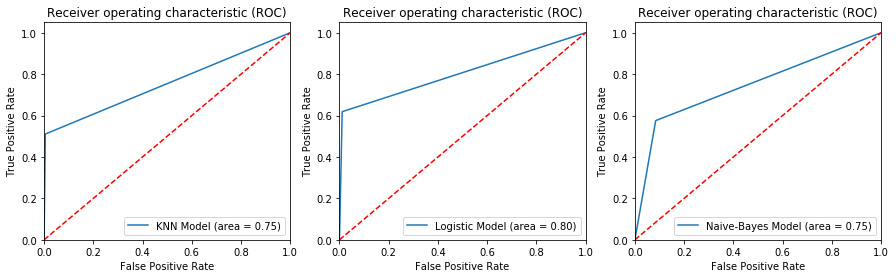

In [59]:
#Evaluate the model using ROC Curve.
print('\n\nReceiver Operating Characteristic (ROC) curve to evalute the classifier output quality.\n If area of curve is closer to 1 which means better the model and if area of curve is closer to 0 which means poor the model.')

knn_fpr, knn_tpr, knn_threshold = metrics.roc_curve(y_test, knn_scaled_predicted_test)
knn_roc_auc = metrics.roc_auc_score(y_test, knn_scaled_predicted_test)
fig1_graph = plt.figure(figsize=(15,4))
fig1_graph.add_subplot(1,3,1)
plt.plot(knn_fpr, knn_tpr, label='KNN Model (area = %0.2f)' % knn_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC)')
plt.legend(loc="lower right")


logistic_fpr, logistic_tpr, logistic_threshold = metrics.roc_curve(y_test, lr_predicted_test)
logistic_roc_auc = metrics.roc_auc_score(y_test, lr_predicted_test)
fig1_graph.add_subplot(1,3,2)
plt.plot(logistic_fpr, logistic_tpr, label='Logistic Model (area = %0.2f)' % logistic_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC)')
plt.legend(loc="lower right")

nb_fpr, nb_tpr, nb_threshold = metrics.roc_curve(y_test, nb_predicted_test)
nb_roc_auc = metrics.roc_auc_score(y_test, nb_predicted_test)
fig1_graph.add_subplot(1,3,3)
plt.plot(nb_fpr, nb_tpr, label='Naive-Bayes Model (area = %0.2f)' % nb_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

##### Question #7 - Give your reasoning on which is the best model in this case and why it performs better?

* Based on the analysis of different models, the logistic Regression model and the KNN model are almost giving similar results of precision, recall, f1 score with a slight variation.  
* The Naive Bayes giving the accuracy less in comaprision to other models.  So the probability of predicting a liability customer buying personal loans is less in Naive Bayes model.
* Comparatively KNN model is the best.
    * As the accuracy of the train and test set is almost similar and also the precsion and recall accuracy is good. 
    * The confusion matrix is also better in comparision to other models.  
    * Also the Type I(False Posssitive) and Type II(False Negative) errors are least in KNN model.
* Hence among the above three algorithm applied on the dataset, K-NN would be the best choice to to predict the likelihood of a liability customer buying personal loans